# HAB Model Showcase: Best Random Forest vs XGBoost

This notebook compares the two saved production candidates for harmful algal bloom prediction:

- **Best Random Forest**: `rf_best_weight.pkl`
- **XGBoost**: `xgb_hab_model.pkl`

Both models are evaluated on the same held-out time period: **2024 July onward plus 2025+**. The positive class is `isHarmful = 1`, so the main priority is high recall while keeping precision and F1 above the project targets.


## Target Criteria

The XGBoost model was trained with the following operating goals for `isHarmful = 1`:

| Metric | Target |
|---|---:|
| Recall | > 0.80 |
| Precision | > 0.30 |
| F1 | > 0.30 |

`pDA`/`pda` and `potential_bloom` are excluded from the feature columns because they are leakage-prone bloom indicators rather than deployment-safe predictors.


In [1]:
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')

TARGET = 'isHarmful'
TARGETS = {'recall': 0.80, 'precision': 0.30, 'f1': 0.30}
TEST_LABEL = '2024 Jul+ and 2025+'


## Load Saved Models

In [2]:
rf_artifact = joblib.load('rf_best_weight.pkl')
xgb_artifact = joblib.load('xgb_hab_model.pkl')

print('Random Forest threshold:', rf_artifact['threshold'])
print('XGBoost threshold      :', xgb_artifact['threshold'])
print('RF feature count       :', len(rf_artifact['features']))
print('XGBoost feature count  :', len(xgb_artifact['feature_columns']))


Random Forest threshold: 0.35
XGBoost threshold      : 0.05
RF feature count       : 29
XGBoost feature count  : 33


## Helper Functions

In [3]:
def month_to_season_label(month):
    if month in (12, 1, 2):
        return 'winter'
    if month in (3, 4, 5):
        return 'spring'
    if month in (6, 7, 8):
        return 'summer'
    return 'fall'


def month_to_season_number(month):
    if month in (12, 1, 2):
        return 1
    if month in (3, 4, 5):
        return 2
    if month in (6, 7, 8):
        return 3
    return 4


def summarize_split(df, mask):
    y = df.loc[mask, TARGET].astype(int)
    return pd.Series({
        'rows': len(y),
        'harmful_count': int(y.sum()),
        'harmful_rate': y.mean(),
    })


def metric_row(model_name, threshold, y_true, probabilities):
    predictions = (probabilities >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, predictions).ravel()
    return {
        'model': model_name,
        'threshold': threshold,
        'accuracy': accuracy_score(y_true, predictions),
        'precision': precision_score(y_true, predictions, zero_division=0),
        'recall': recall_score(y_true, predictions, zero_division=0),
        'f1': f1_score(y_true, predictions, zero_division=0),
        'roc_auc': roc_auc_score(y_true, probabilities),
        'tn': tn,
        'fp': fp,
        'fn': fn,
        'tp': tp,
    }


def target_status(row):
    return (
        row['recall'] > TARGETS['recall']
        and row['precision'] > TARGETS['precision']
        and row['f1'] > TARGETS['f1']
    )


## Data Overview

In [4]:
df_overview = pd.read_csv('hab_ndbc_merged_cleaned.csv')
test_mask = ((df_overview['year'] == 2024) & (df_overview['month'] > 6)) | (df_overview['year'] >= 2025)

summary = pd.DataFrame({
    'Full dataset': summarize_split(df_overview, df_overview.index == df_overview.index),
    TEST_LABEL: summarize_split(df_overview, test_mask),
}).T
summary['harmful_rate'] = (summary['harmful_rate'] * 100).round(1).astype(str) + '%'
summary


,rows,harmful_count,harmful_rate
Full dataset,3078.0,195.0,6.3%
2024 Jul+ and 2025+,535.0,74.0,13.8%


## Evaluate Best Random Forest

The best RF artifact came from the weighted Random Forest sweep. It uses a numeric feature table with station/date/leakage columns removed, plus a 52-week lagged bloom-rate feature.


In [5]:
rf_df = pd.read_csv('hab_ndbc_merged_cleaned.csv')
rf_df = rf_df.sort_values('week_start').reset_index(drop=True)
rf_df['season'] = rf_df['month'].map(month_to_season_number)
rf_df['rolling_bloom_rate'] = (
    rf_df.groupby('station')[TARGET]
    .transform(lambda x: x.shift(1).rolling(window=52, min_periods=1).mean())
    .fillna(0)
)

rf_drop_cols = [
    'week_start', 'station', 'sample_date',
    'latitude', 'longitude', 'pda', 'potential_bloom', 'station_id',
]
rf_test_mask = ((rf_df['year'] == 2024) & (rf_df['month'] > 6)) | (rf_df['year'] >= 2025)

rf_X_all = rf_df.drop(columns=rf_drop_cols + [TARGET])
rf_X_test = rf_X_all.loc[rf_test_mask, rf_artifact['features']]
rf_y_test = rf_df.loc[rf_test_mask, TARGET].astype(int)
rf_prob = rf_artifact['model'].predict_proba(rf_X_test)[:, 1]

rf_metrics = metric_row(
    'Best Random Forest',
    rf_artifact['threshold'],
    rf_y_test,
    rf_prob,
)
rf_metrics


{'model': 'Best Random Forest',
 'threshold': 0.35,
 'accuracy': 0.8186915887850468,
 'precision': 0.4049586776859504,
 'recall': 0.6621621621621622,
 'f1': 0.5025641025641026,
 'roc_auc': 0.8478337339508706,
 'tn': 389,
 'fp': 72,
 'fn': 25,
 'tp': 49}

## Evaluate XGBoost

The XGBoost artifact is a full preprocessing-and-model pipeline. It keeps categorical station information through one-hot encoding and uses `scale_pos_weight` to emphasize the harmful class.


In [6]:
xgb_df = pd.read_csv('hab_ndbc_merged.csv', parse_dates=['week_start', 'sample_date'])
xgb_df = xgb_df.sort_values(['station', 'week_start']).reset_index(drop=True)
xgb_df['season'] = xgb_df['month'].map(month_to_season_label)
xgb_df['rolling_bloom_rate_52w'] = (
    xgb_df.groupby('station')[TARGET]
    .transform(lambda s: s.shift(1).rolling(window=52, min_periods=1).mean())
    .fillna(0)
)
xgb_df = xgb_df.sort_values('week_start').reset_index(drop=True)

xgb_drop_cols = [col for col in [TARGET, 'week_start', 'sample_date', 'pDA', 'pda', 'potential_bloom'] if col in xgb_df.columns]
xgb_test_mask = ((xgb_df['year'] == 2024) & (xgb_df['month'] > 6)) | (xgb_df['year'] >= 2025)

xgb_X_all = xgb_df.drop(columns=xgb_drop_cols)
xgb_X_test = xgb_X_all.loc[xgb_test_mask, xgb_artifact['feature_columns']]
xgb_y_test = xgb_df.loc[xgb_test_mask, TARGET].astype(int)
xgb_prob = xgb_artifact['model'].predict_proba(xgb_X_test)[:, 1]

xgb_metrics = metric_row(
    'XGBoost',
    xgb_artifact['threshold'],
    xgb_y_test,
    xgb_prob,
)
xgb_metrics


{'model': 'XGBoost',
 'threshold': 0.05,
 'accuracy': 0.7738317757009345,
 'precision': 0.36416184971098264,
 'recall': 0.8513513513513513,
 'f1': 0.5101214574898786,
 'roc_auc': 0.8543120126634227,
 'tn': 351,
 'fp': 110,
 'fn': 11,
 'tp': 63}

## Results Comparison

In [7]:
comparison = pd.DataFrame([rf_metrics, xgb_metrics])
comparison['meets_targets'] = comparison.apply(target_status, axis=1)

metric_cols = [
    'model', 'threshold', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc',
    'tn', 'fp', 'fn', 'tp', 'meets_targets'
]
comparison = comparison[metric_cols]
comparison.round(4)


,model,threshold,accuracy,precision,recall,f1,roc_auc,tn,fp,fn,tp,meets_targets
0,Best Random Forest,0.35,0.8187,0.4050,0.6622,0.5026,0.8478,389,72,25,49,False
1,XGBoost,0.05,0.7738,0.3642,0.8514,0.5101,0.8543,351,110,11,63,True


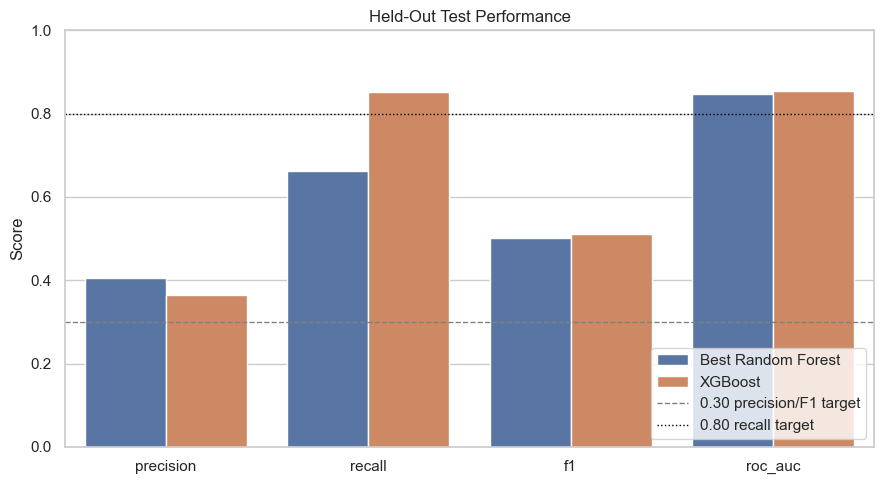

In [8]:
plot_metrics = comparison.melt(
    id_vars='model',
    value_vars=['precision', 'recall', 'f1', 'roc_auc'],
    var_name='metric',
    value_name='score',
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=plot_metrics, x='metric', y='score', hue='model', ax=ax)
ax.axhline(TARGETS['precision'], color='gray', linestyle='--', linewidth=1, label='0.30 precision/F1 target')
ax.axhline(TARGETS['recall'], color='black', linestyle=':', linewidth=1, label='0.80 recall target')
ax.set_ylim(0, 1)
ax.set_title('Held-Out Test Performance')
ax.set_xlabel('')
ax.set_ylabel('Score')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()


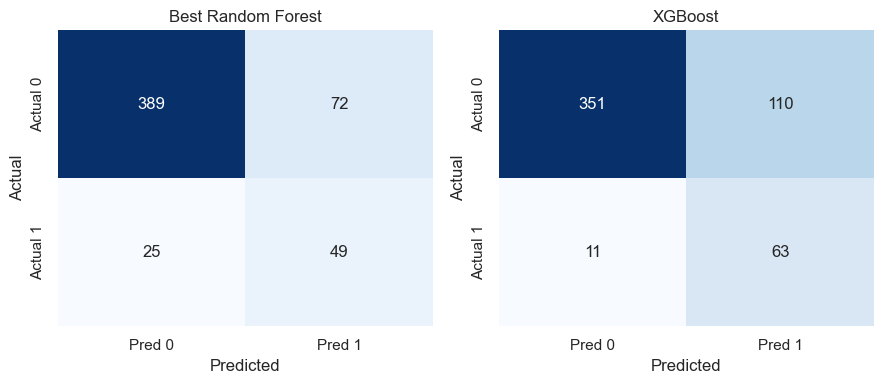

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, row in zip(axes, comparison.itertuples(index=False)):
    cm = np.array([[row.tn, row.fp], [row.fn, row.tp]])
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False,
        xticklabels=['Pred 0', 'Pred 1'],
        yticklabels=['Actual 0', 'Actual 1'],
        ax=ax,
    )
    ax.set_title(row.model)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()


## Feature Importance

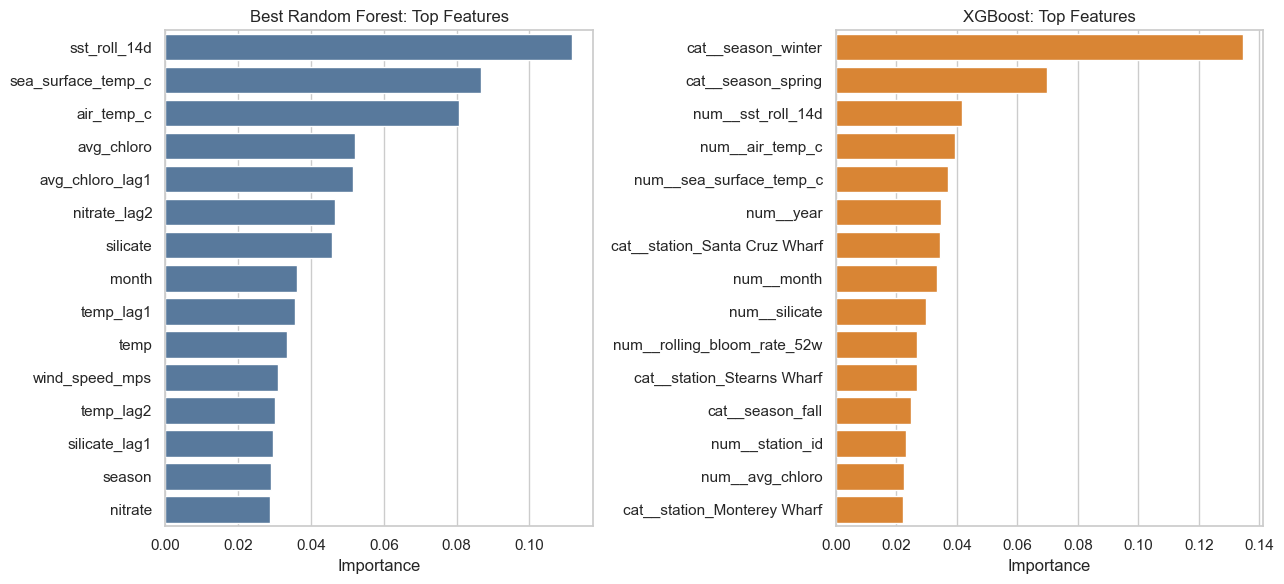

In [10]:
rf_importance = (
    pd.DataFrame({
        'feature': rf_artifact['features'],
        'importance': rf_artifact['model'].feature_importances_,
    })
    .sort_values('importance', ascending=False)
    .head(15)
)

xgb_importance = pd.read_csv('xgb_hab_feature_importance.csv').head(15)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
sns.barplot(data=rf_importance, y='feature', x='importance', ax=axes[0], color='#4C78A8')
axes[0].set_title('Best Random Forest: Top Features')
axes[0].set_xlabel('Importance')
axes[0].set_ylabel('')

sns.barplot(data=xgb_importance, y='feature', x='importance', ax=axes[1], color='#F58518')
axes[1].set_title('XGBoost: Top Features')
axes[1].set_xlabel('Importance')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()


## Takeaway

On the held-out test period, **XGBoost is the stronger final model for the project goal**. It catches more harmful blooms than the best Random Forest and clears all target thresholds:

| Model | Precision | Recall | F1 | Meets Targets? |
|---|---:|---:|---:|---|
| Best Random Forest | 0.405 | 0.662 | 0.503 | No, recall is below 0.80 |
| XGBoost | 0.364 | 0.851 | 0.510 | Yes |

The tradeoff is that XGBoost produces more false positives, but that is acceptable for this project because missing harmful blooms is the higher-cost error.
